Importing Packages

In [38]:
from astrotime.loader import load_lightcurve
from astrotime.plotting import plot_lightcurve
from astrotime.periodogram import compute_lombscargle, plot_periodogram, find_best_period
from astrotime.phasefold import phase_fold, plot_fold
from astrotime.autocorrelation import compute_acf, find_acf_peaks, plot_acf, estimate_timescale
from astrotime.lightcurve import LightCurve

Loading the Lightcurve Datafile

In [45]:
# Loading the CSV file of the lightcurve of RR Lyrae Variable stars
lc = load_lightcurve("lightcurve_dataset.csv")
print(lc.head())

          time       flux   flux_err
0  1683.356471 -19165.498  51.742780
1  1683.357859 -19523.283  51.720253
2  1683.359248 -19876.450  51.699320
3  1683.360637 -20180.451  51.686375
4  1683.362026 -20730.244  51.635700


Plotting the Raw Lightcurve Data (time vs flux)

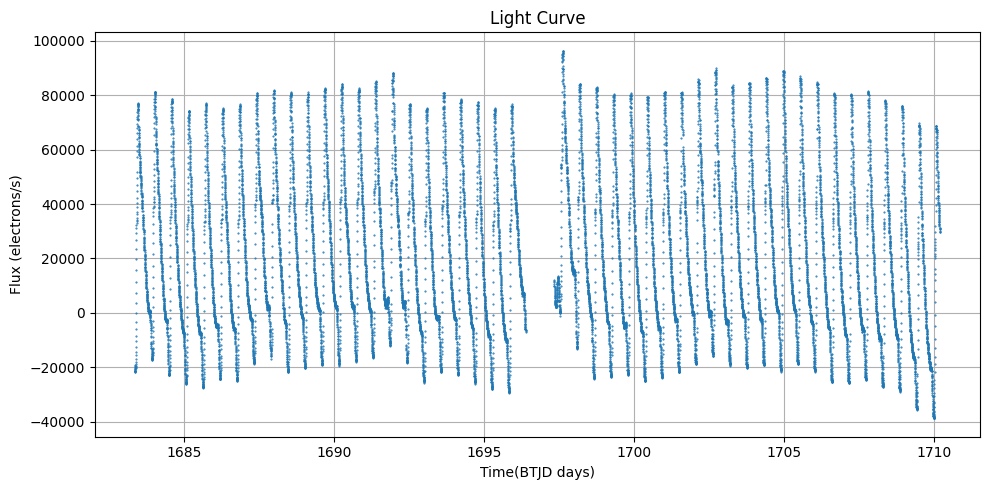

In [47]:
# Plotting the raw lightcurve
plot_lightcurve(lc)

Lomb-Scargle Periodogram



Recovered Best Period = 0.5670533455924104


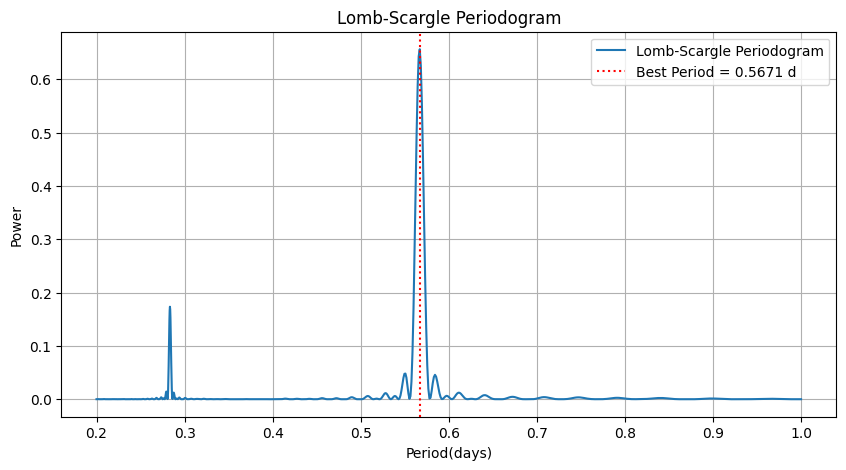

In [48]:
# Calculating the best period Using Lomb-Scargle Periodogram
time =lc["time"].to_numpy()
flux =lc["flux"].to_numpy()
flux_err = lc["flux_err"].to_numpy()
periods, power = compute_lombscargle(time,flux,min_period=0.2,max_period=1.0)
best_period,best_power = find_best_period(periods,power)
print("Recovered Best Period =",best_period)
plot_periodogram(periods, power, best_period=best_period,show=True)

Phasefold of Lightcurve

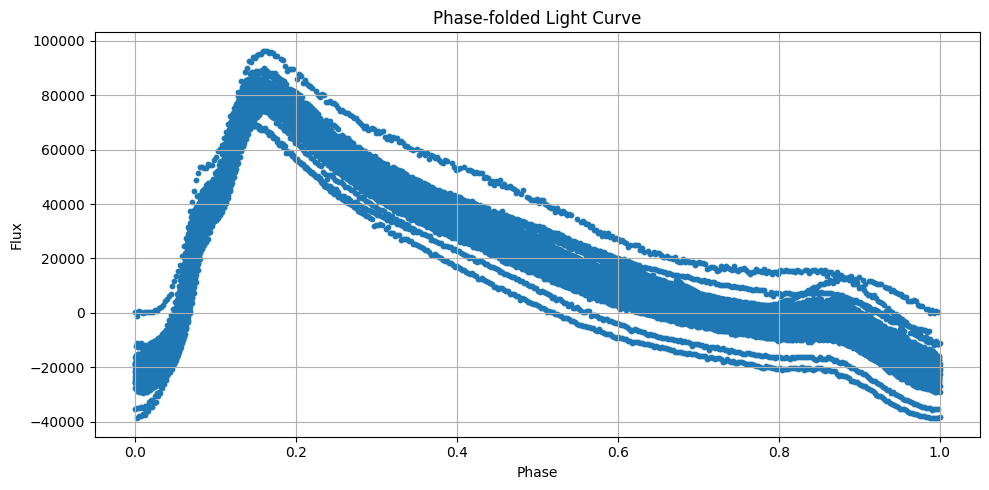

In [49]:
# Phasefold the light curve using the best period to check if the period is consistant or not 
phase, folded_flux = phase_fold(time, flux, best_period, t0=None)
plot_fold(phase,folded_flux, show=True)

Statistical Parameters of the Lightcurve

In [51]:
# Statistical parameters of the light curve
lc = LightCurve(
    time=time,
    flux=flux,
    flux_err=flux_err
)

print(lc.summary())

{'n_points': 18292, 'mean_flux': 20172.205379121162, 'median_flux': 13699.7845, 'std_flux': 29116.313608008226, 'rms_flux': 29116.313608008226, 'amplitude': 135152.285, 'duration': 26.8499443668195}


Autocorrelation Function

0.5569457006708944


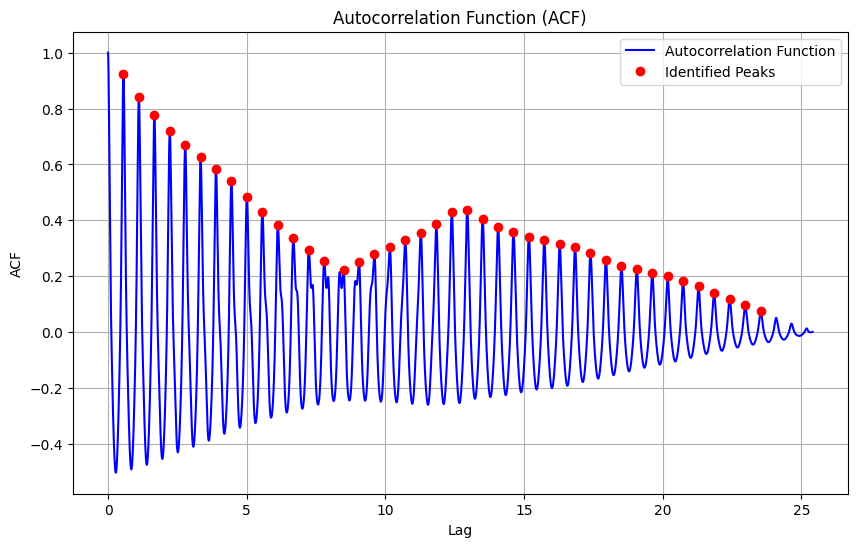

In [52]:
# Autocorrelatio function 
lags, acf, dt = compute_acf(time, flux)
peaks, properties, dt = find_acf_peaks(lags, acf, dt)
timescale = estimate_timescale(lags, peaks, properties)
print(timescale)
plot_acf(lags, acf, peaks)